<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/leon/Asah_Fetch_A25_CS328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [1]:
# Library Essential
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import shutil
from google.colab import files
from datetime import datetime

# Library pre-processing data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Library save model (joblib)
import joblib

In [2]:
# Upload file .json untuk API key
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle.json
API Key Received


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
  0% 0.00/7.15M [00:00<?, ?B/s]
100% 7.15M/7.15M [00:00<00:00, 700MB/s]
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
  0% 0.00/14.5M [00:00<?, ?B/s]
100% 14.5M/14.5M [00:00<00:00, 1.38GB/s]


In [4]:
!unzip "online-retail-uci-dataset.zip"
!unzip "online-retail-ii-uci.zip"

Archive:  online-retail-uci-dataset.zip
  inflating: Online Retail.csv       
Archive:  online-retail-ii-uci.zip
  inflating: online_retail_II.csv    


# **Load Dataset**

Load kedua dataset yang digunakan, yaitu
- Online Retail Dataset (UCI)
- Online Retail Dataset II (UCI)

In [5]:
# Simpan dataset dari csv ke DataFrame Pandas
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [6]:
df_1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [7]:
df_2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) untuk mencari dari pola data pembelian

In [8]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [9]:
# Gabung menjadi 1 DataFrame
df_all = pd.concat([df_1, df_2])
df_all.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Informasi Dataset

In [10]:
# Tampilkan info dataset
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


Sepertinya terdapat cukup banyak data yang hilang, terutama pada CustomerID. Perlu dilakukan pembersihan data setelah EDA.

In [11]:
df_all.describe()

,Quantity,Price,CustomerID
count,1.609280e+06,1.609280e+06,1.231193e+06
mean,9.808698e+00,4.636499e+00,1.531243e+04
std,1.892047e+02,1.152285e+02,1.702901e+03
min,-8.099500e+04,-5.359436e+04,1.234600e+04
25%,1.000000e+00,1.250000e+00,1.396900e+04
50%,3.000000e+00,2.100000e+00,1.522000e+04
75%,1.000000e+01,4.130000e+00,1.679500e+04
max,8.099500e+04,3.897000e+04,1.828700e+04


Di sini juga terlihat, ada jumlah (Quantity) pembelian yang mencapai nilai negatif (-80995) dan harga (Price) negatif (-53594,36) yang tidak masuk akal. Data ini perluu ditangani pada tahap pembersihan data.

### Korelasi Antar Variabel

['Invoice', 'StockCode', 'InvoiceDate', 'Country']


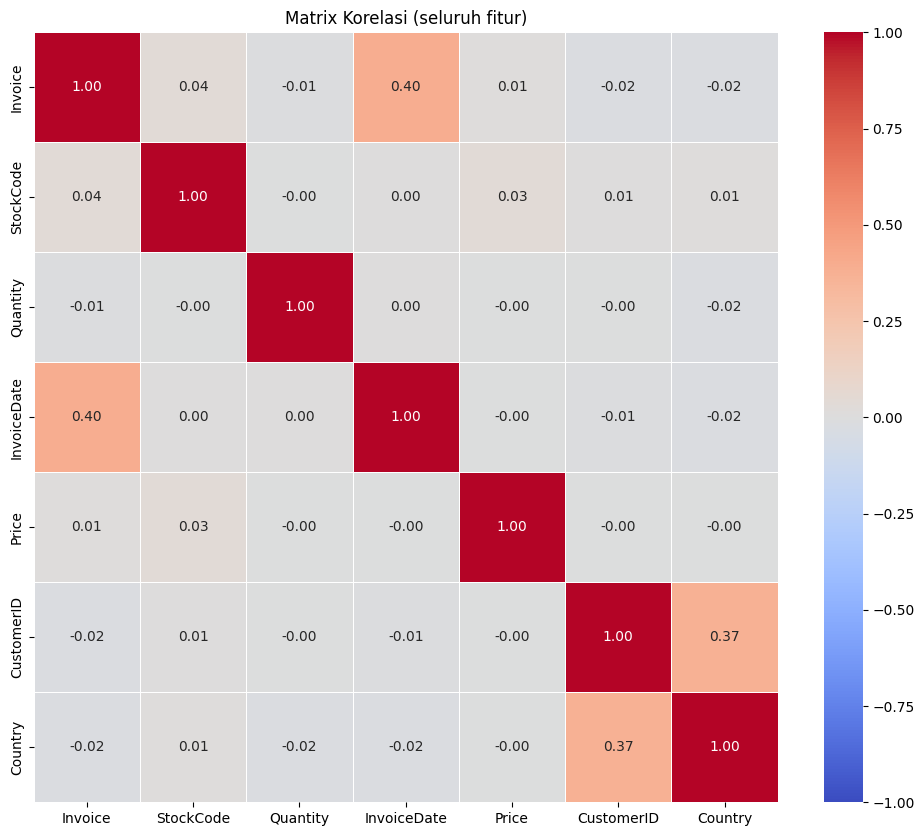

In [12]:
# Encode variabel kategorikal yang relevan
label_encoder = LabelEncoder()
df_lencoder = df_all.copy()
df_lencoder = df_lencoder.drop('Description', axis=1)

category_features = ['Invoice', 'StockCode', 'InvoiceDate', 'Country']
print(category_features)
for col in category_features:
  df_lencoder[col] = label_encoder.fit_transform(df_all[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr()

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi (seluruh fitur)')
plt.show()

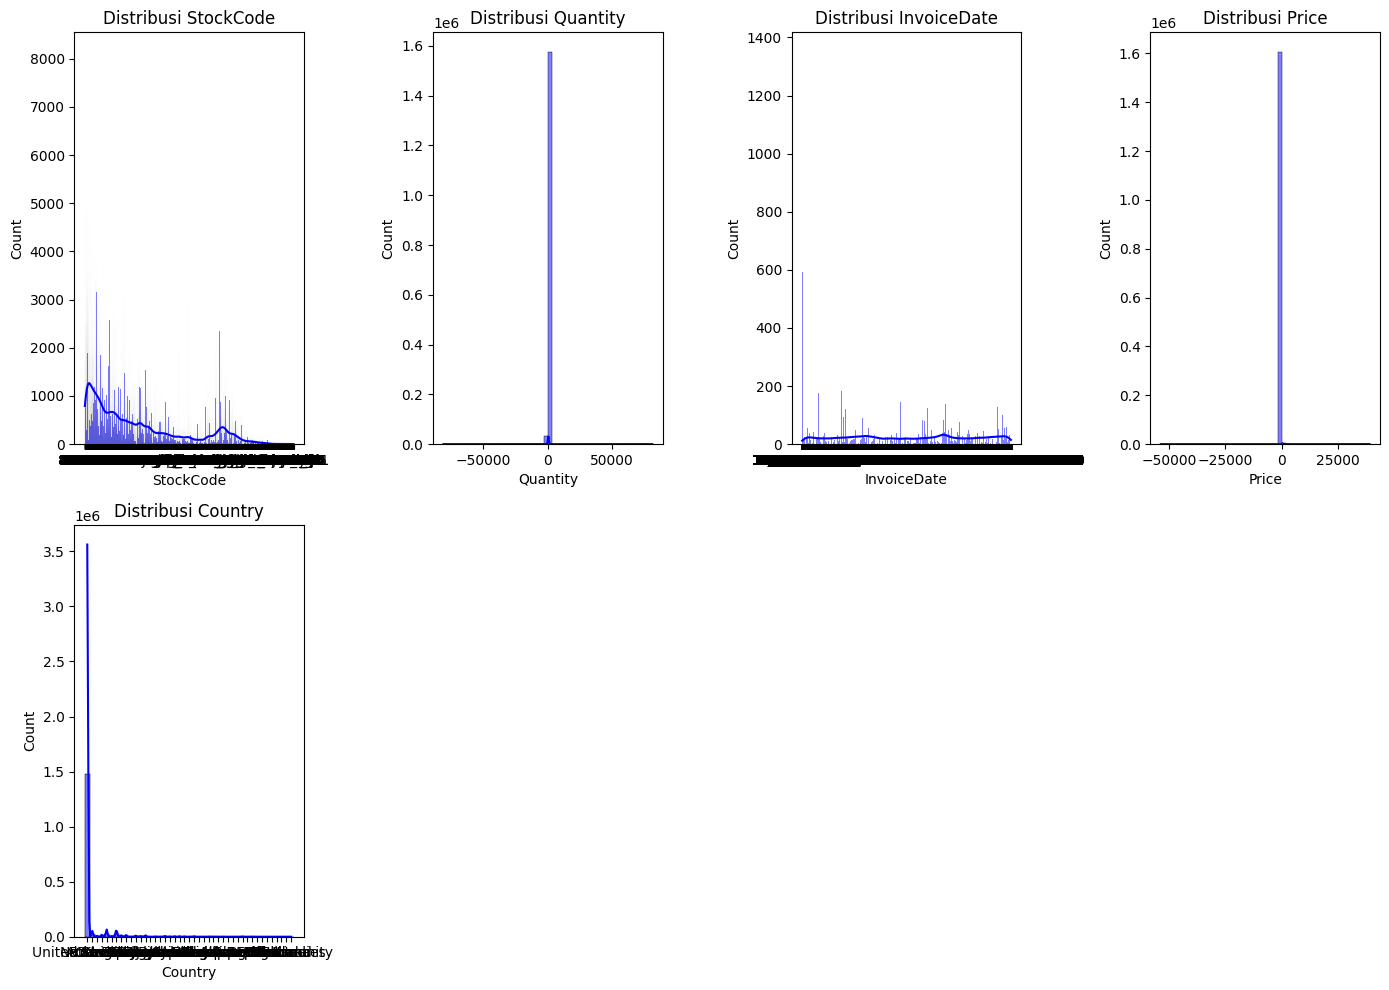

In [13]:
column_display = ['StockCode', 'Quantity', 'InvoiceDate', 'Price', 'Country']
plt.figure(figsize=(14, 10))

for i, column in enumerate(column_display, 1):
  plt.subplot(2, 4, i)
  sns.histplot(df_all[column], bins=50, kde=True, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

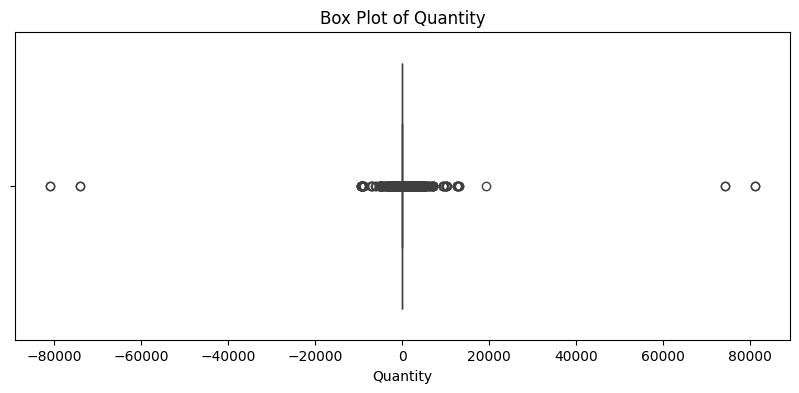

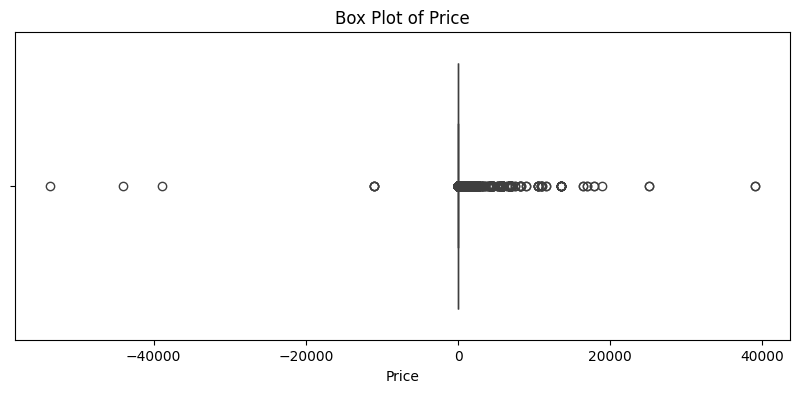

In [14]:
# Pemilihan field dilakukan manual karena CustomerID tidak termasuk numerik;
# namun pada DataFrame dikategorikan sebagai numerik (float64)
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 4))
  sns.boxplot(x=df_all[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

# **Data Cleaning & Preprocessing**

### Pembersihan Data

#### Cek missing values dan data duplikat

In [15]:
missing_values = df_all.isnull().sum()
missing_values[missing_values > 0]

,0
Description,5836
CustomerID,378087


In [16]:
df_all.duplicated().sum()

np.int64(39603)

Ternyata, missing value terdapat pada CustomerID dan Description; keduanya berupa categorical variable (non numerik). Untuk data dengan CustomerID yang missing, data di-drop karena tidak bisa digunakan untuk RFM. Untuk data dengan Description yang hilang, bisa dilakukan pencarian data melalui StockCode yang sama.

Selain itu, terdapat 39603 data yang terduplikasi, sehingga harus dihapus.

In [17]:
# Filter data yang memiliki customer ID dan simpan hasil filter ke df_clean
filter_custID = df_all['CustomerID'].notnull()
df_clean = df_all[filter_custID]

# Hapus data duplikat
df_clean = df_clean.drop_duplicates()

In [18]:
# Cek informasi dataset setelah penghapusan nilai duplikat & missing valuue
df_all.info()
print("\n")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


<class 'pandas.core.frame.DataFrame'>
Index: 1199489 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1199489 non-null  object 
 1   StockCode    1199489 non-null  object 
 2   Description  1199489 non-null  object 
 3   Quantity     1199489 non-null  int64  
 4   InvoiceDate

Ternyata dengan penghapusan CustomerID yang missing, deskripsi barang yang missing juga ikut hilang dari dataset. Dengan ini, pemrosesan akan data akan dilanjutkan.

#### Hapus data negatif

In [19]:
df_clean.describe()

,Quantity,Price,CustomerID
count,1.199489e+06,1.199489e+06,1.199489e+06
mean,1.246246e+01,3.626171e+00,1.530238e+04
std,2.130975e+02,7.085152e+01,1.702425e+03
min,-8.099500e+04,0.000000e+00,1.234600e+04
25%,2.000000e+00,1.250000e+00,1.395600e+04
50%,5.000000e+00,1.950000e+00,1.519400e+04
75%,1.200000e+01,3.750000e+00,1.678800e+04
max,8.099500e+04,3.897000e+04,1.828700e+04


Hapus nilai tidak relevan, seperti harga dan jumlah pembelian negatif

In [20]:
filter_price = df_clean['Price'] >= 0
df_clean = df_clean[filter_price]
filter_quantity = df_clean['Quantity'] >= 0
df_clean = df_clean[filter_quantity]

In [21]:
df_clean.describe()

,Quantity,Price,CustomerID
count,1.172227e+06,1.172227e+06,1.172227e+06
mean,1.338870e+01,3.187174e+00,1.530937e+04
std,1.591446e+02,2.740972e+01,1.701791e+03
min,1.000000e+00,0.000000e+00,1.234600e+04
25%,2.000000e+00,1.250000e+00,1.396900e+04
50%,6.000000e+00,1.950000e+00,1.520500e+04
75%,1.200000e+01,3.750000e+00,1.679400e+04
max,8.099500e+04,1.095350e+04,1.828700e+04


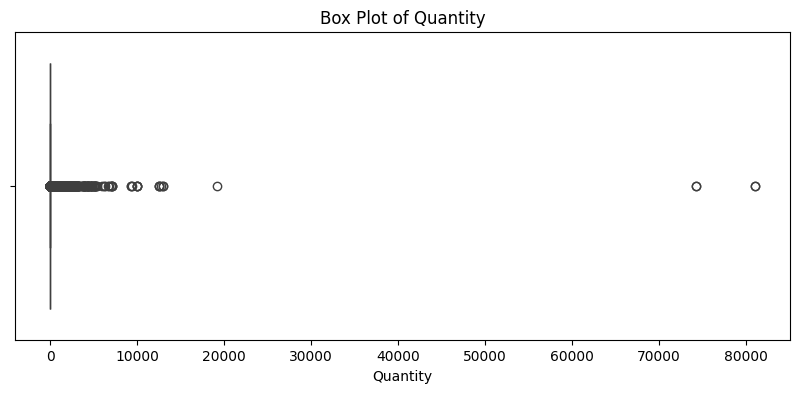

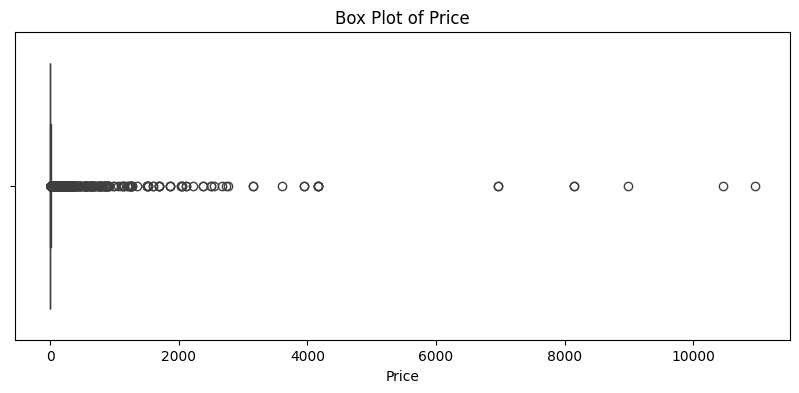

In [22]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 4))
  sns.boxplot(x=df_clean[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172227 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1172227 non-null  object 
 1   StockCode    1172227 non-null  object 
 2   Description  1172227 non-null  object 
 3   Quantity     1172227 non-null  int64  
 4   InvoiceDate  1172227 non-null  object 
 5   Price        1172227 non-null  float64
 6   CustomerID   1172227 non-null  float64
 7   Country      1172227 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 80.5+ MB


#### Outlier (?)



Cek data outlier

In [24]:
# # Data numerik outlier dicari dan dibuang
# # Pemilihan field dilakukan manual karena CustomerID tidak termasuk numerik;
# # namun pada DataFrame dikategorikan sebagai numerik (float64)
# numerik = ['Quantity', 'Price']

# print("Sebelum drop outlier:", df_clean.shape)
# for col in numerik:
#   # Cari kuantil 1 dan 3 setiap untuk mendapatkan batas bawah & batas atas
#   Q1 = df_clean[col].quantile(0.25)
#   Q3 = df_clean[col].quantile(0.75)
#   IQR = Q3 - Q1
#   batas_bawah = Q1 - 1.5 * IQR
#   batas_atas = Q3 + 1.5 * IQR

#   # Outlier = data yang di nilainya di bawah batas bawah/di atas batas atas
#   outlier = df_clean[(df_clean[col] < batas_bawah) | (df_clean[col] > batas_atas)]
#   # print(outlier)
#   print(Q1)
#   print(Q3)
#   print("Kolom", col, "memiliki batas bawah", batas_bawah, "dan batas atas", batas_atas)

#   # df = df.drop(outlier.index)

# # print("Setelah drop outlier:", df_clean.shape)

In [25]:
# # Data numerik outlier dicari dan dibuang
# # Pemilihan field dilakukan manual karena CustomerID tidak termasuk numerik;
# # namun pada DataFrame dikategorikan sebagai numerik (float64)
# numerik = ['Quantity', 'Price']

# print("Sebelum drop outlier:", df_all.shape)
# for col in numerik:
#   # Cari kuantil 1 dan 3 setiap untuk mendapatkan batas bawah & batas atas
#   Q1 = df_all[col].quantile(0.25)
#   Q3 = df_all[col].quantile(0.75)
#   IQR = Q3 - Q1
#   batas_bawah = Q1 - 1.5 * IQR
#   batas_atas = Q3 + 1.5 * IQR

#   # Outlier = data yang di nilainya di bawah batas bawah/di atas batas atas
#   outlier = df_all[(df_all[col] < batas_bawah) | (df_all[col] > batas_atas)]
#   # print(outlier)
#   print(Q1)
#   print(Q3)
#   print("Kolom", col, "memiliki batas bawah", batas_bawah, "dan batas atas", batas_atas)

#   # df = df.drop(outlier.index)

# # print("Setelah drop outlier:", df_clean.shape)

### Preprocessing Data

#### Konversi Satuan Waktu

Tanggal pembelian yang terdapat di dataset kurang relevan dengan kondisi saat ini (data dari tahun 2009-2011). Oleh karena itu, ditambahkan 10 tahun pada pada tanggal untuk menjadikan tanggal tersebut relevan; terutama untuuk faktor Recency dari RFM.

In [27]:
date_string = "12/1/10 8:26"
date_format = "%m/%d/%y %H:%M"

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceDateNew'] = df_clean['InvoiceDate'] + pd.DateOffset(years=10)

df_clean.head()

/tmp/ipython-input-4096998907.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,InvoiceDateNew
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2020-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2020-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2020-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2020-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2020-12-01 08:26:00


In [30]:
df_clean = df_clean.sort_values('InvoiceDateNew')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,InvoiceDateNew
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2019-12-01 07:45:00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,2019-12-01 07:45:00
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2019-12-01 07:45:00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2019-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2019-12-01 07:45:00
...,...,...,...,...,...,...,...,...,...
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2021-12-09 12:50:00
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2021-12-09 12:50:00
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2021-12-09 12:50:00
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France,2021-12-09 12:50:00
